In [1]:

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, HMC
from IPython.core.pylabtools import figsize
import numpy as np
import pandas as pd

from pathlib import Path
import glob
from matplotlib import pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler

from pyro.infer.autoguide import init_to_value


# Parameter determination for function
Goal here is to extract peak centers using the Pyro Bi-Lorentzian model and then build a simple regression model using those values. The peak centers come with uncertainties, to first order approx, we assume these uncertainties are the largest driver of predicted temperatrure uncertainties

## Set up function
Here we import the data, define a bi-Lorentzian function and demonstrate the impact of different values of center 1 and center 2 (A and B, respectively) on the simulated spectra.  We drop the last point the first and last obs. the first obs was made with lower laser power (and as such can introduce uncertainty) and the last observation appears to be an outlier. Records indicate the set temp was 0.0 C but the spectra is near match to -20.0 C. It is either a recording error or an operator error i.e. I forgot to hit enter on the drywell after keying in the new temp value (0 C)

In [2]:
temps_ = ['25', '30', '35',
       '40', '45', '50', '45', '40', '35', '30', '25', '20']
temps = np.array(temps_, dtype=float)

temps



array([25., 30., 35., 40., 45., 50., 45., 40., 35., 30., 25., 20.])

Index(['Unnamed: 0', 'frequency', '25up', '30up', '35up', '40down', '45down',
       '50', '45', '40', '35', '30', '25', '20'],
      dtype='object')


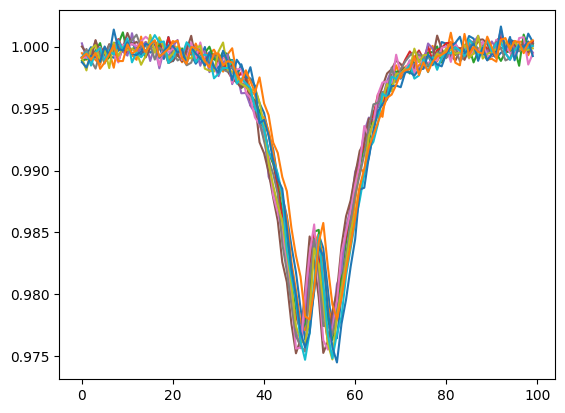

In [3]:
## import data file
fpath = './saved_data/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, :-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', "-20"], inplace= True)
print(df.columns)
df.iloc[:, 2:].plot(legend= False)

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

#scale x axis to 0-100
sc = MinMaxScaler()
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()*100

torch.set_default_dtype(torch.float64)


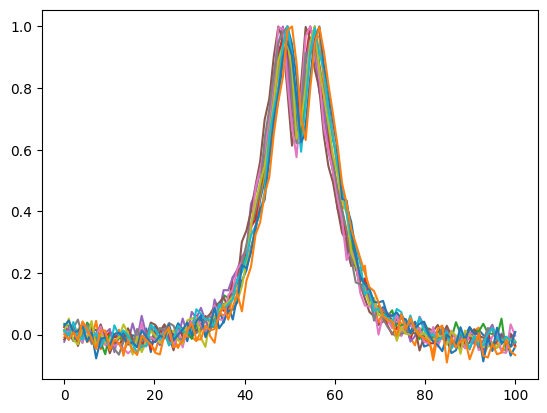

In [4]:
# plot baseline subtracted  y data
y_esr = y_esr.apply(lambda x: x - x[:10].mean())#+0.01
y_esr = -1*y_esr
y_esr = y_esr.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr);
#plt.xlim(40, 80)

In [5]:
# plt.plot(x_esr, y_esr.iloc[:, -2:], 'x')
len(temps)==y_esr.shape[1]


True

In [6]:
y_esr.shape

(100, 12)

In [7]:
from scipy.signal import find_peaks

peak_A, peak_B = [], []

for j in range(y_esr.shape[1]):
    y_ = y_esr.iloc[:, j].values
    peaks, properties = find_peaks(
        y_,
        height=0.75,      # minimum peak height
        distance=5,      # minimum spacing (points)
        prominence=0.02   # suppress noise
    )
    peak_A.append(peaks[0])    
    peak_B.append(peaks[1])
    


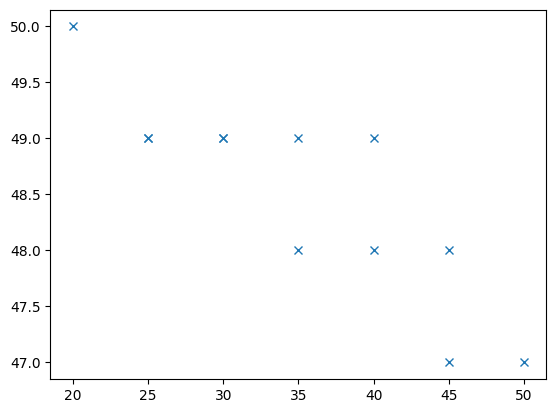

In [8]:
plt.plot(temps, peak_A, 'x')

In [9]:
#numpy version of function
def F_np(x_in, A, X, Amp, G1, G2):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    A_reshaped = A[None, :]  # Shape (1, num_samples)
    X_reshaped = X[None, :]  # Shape (1, num_samples)
    B_reshaped = A_reshaped + X_reshaped  # Shape (1, num_samples)
    Amp_reshaped = Amp[None, :] # Shape (1, num_samples)
    G1_reshaped = G1[None, :] # New: Reshape gamma1
    G2_reshaped = G2[None, :] # New: Reshape gamma2
    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F


# A function to sample values of A and B and plot resulting function.
def F_samples():
    A = pyro.sample("A", dist.Uniform(40, 57))
    X = pyro.sample("X", dist.Normal(6., 2.0)).double()
    B = A + X
    # Sample gamma1 and gamma2 as pyro variables
    gamma1 = pyro.sample("gamma1_sample", dist.Uniform(1., 7.0)) # Sample gamma1
    gamma2 = pyro.sample("gamma2_sample", dist.Uniform(1., 7.0)) # Sample gamma2
    amp = pyro.sample("amp", dist.Normal(3.0, 0.25) )

    # Use the sampled gamma values in the function
    f_sim = lambda xi: (amp) *(0.5*gamma1)/((xi-A)**2 + (0.5*gamma1)**2) + (amp) *(0.5*gamma2)/((xi-B)**2 + (0.5*gamma2)**2)
    plt.plot(x_scale, f_sim(x_scale))
    # Update title to show sampled gamma values
    plt.title('A:' + str(A.numpy()) + ' B:' + str(B.numpy()) + ' G1:' + str(gamma1.numpy()) + ' G2:' + str(gamma2.numpy()))



## Define data we will start with and plot.

In [10]:

# this will be the data we'll start with, shown as red circles
def dataslicer(x, y, col1 =1 ,col2=2):
    x_scale_tensor = torch.tensor(x_scale).double()
    # squeeze the selected column to produce a 1-D tensor (N,) instead of (N,1)
    y_vals = y_esr.iloc[:, col1:col2].values.squeeze()
    y_scale_tensor = torch.tensor(y_vals).double()
    return x_scale_tensor, y_scale_tensor



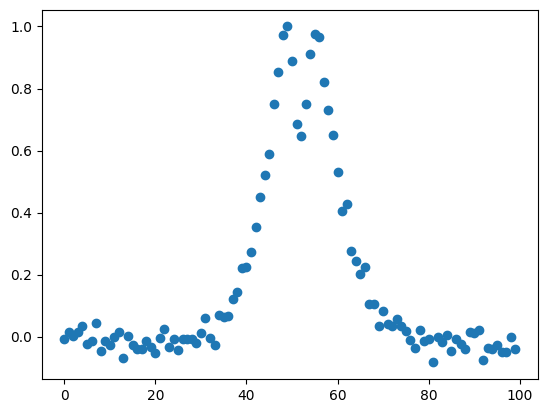

In [11]:
plt.plot(y_esr.iloc[:, 1].values, 'o')
#plt.xlim(40,70)

## Set up and run Bayesian inference

In [12]:
# define the model
# Here we assume that we know the noise variance in the data = 0.1,
# though this can be set to another parameter to learn.

x_obs, y_obs = dataslicer(x_scale, y_esr, col1=0, col2=1)
data = (x_obs.clone().detach().double(), y_obs.clone().detach().double())

def model(data):
    A = pyro.sample("A", dist.Normal(53., 1.0)).double() # sample a value for A uniformly between 0 and 10
    X =  pyro.sample("X", dist.Normal(8., 0.5)).double()
    B = A + X # sample a value for B uniformly between 0 and 10
    gamma1 = pyro.sample("gamma1", dist.Normal(7.0, 1.5)).double()
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(6.0, 2.5)).double()
    amp = pyro.sample("amp", dist.LogNormal(3.0, 0.25)).double()
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()

    F =  (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma2) / ((data[0] - B)**2 + (0.5 * gamma2)**2)
    # ensure F is a 1-D mean vector matching y_obs
    F = F.squeeze()

    #with pyro.plate("data", data[0].size(0)):
    pyro.sample("obs", dist.MultivariateNormal(F, var * torch.eye(data[1].shape[0]).double()), obs=data[1])

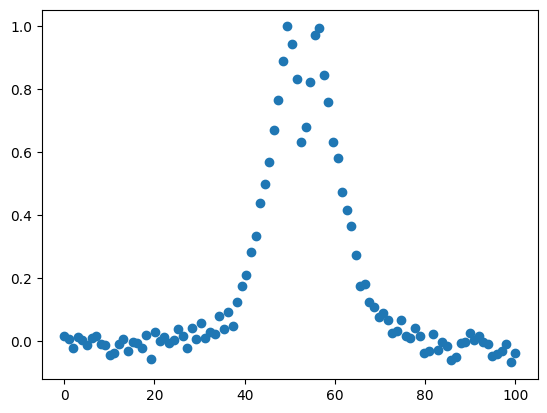

In [13]:
plt.plot(x_obs, y_obs, 'o')
#plt.xlim(40, 70)

## Get results and plot

Here we sample the data, 10 "pixels" at a time. Given the initial guess we fit the sampled spectra each time and estimate the peak centers and the estimated error in peak positions. From the simulation above we know that given the entire spectra we can estimate the peak position with an error of 2.27 K

Here we examine what happens if we decrease our data density i.e reduce the resolution of the measurement

0


Sample: 100%|██████████| 2200/2200 [01:08, 32.02it/s, step size=4.96e-01, acc. prob=0.931]


#################


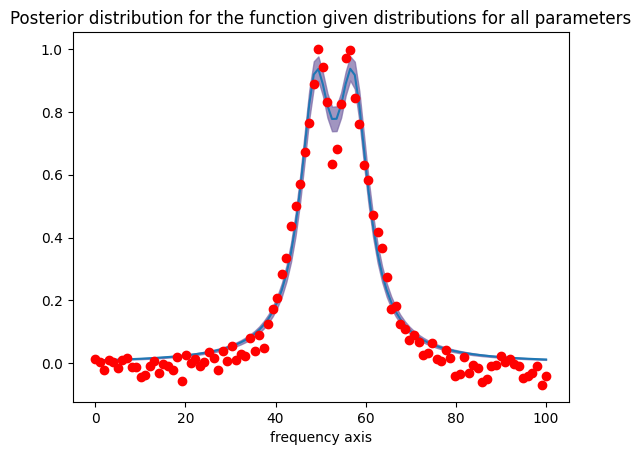

#################
1


Sample: 100%|██████████| 2200/2200 [00:57, 38.39it/s, step size=5.56e-01, acc. prob=0.892]


#################


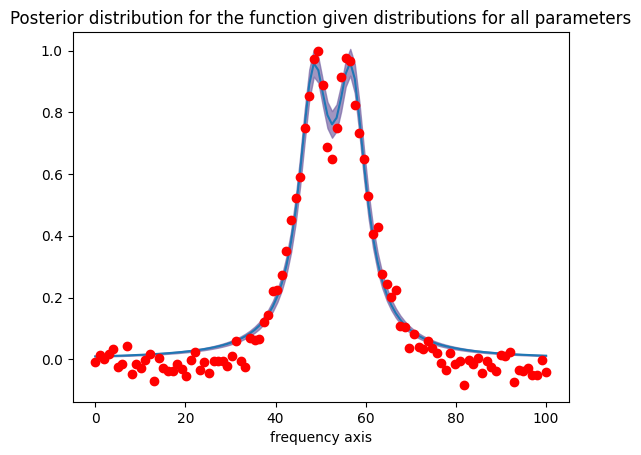

#################
2


Sample: 100%|██████████| 2200/2200 [00:59, 36.96it/s, step size=5.93e-01, acc. prob=0.909]


#################


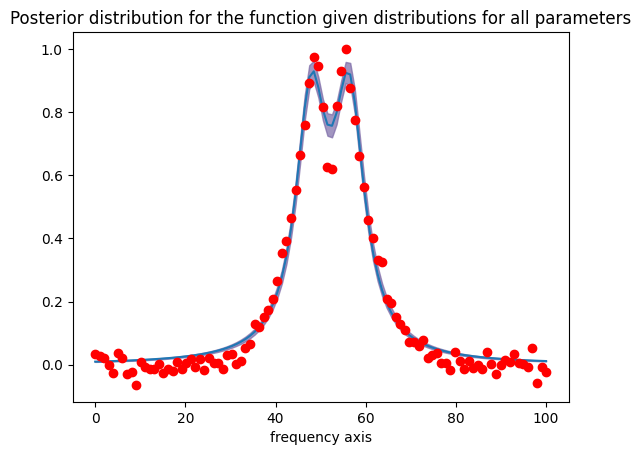

#################
3


Sample: 100%|██████████| 2200/2200 [01:00, 36.40it/s, step size=5.50e-01, acc. prob=0.919]


#################


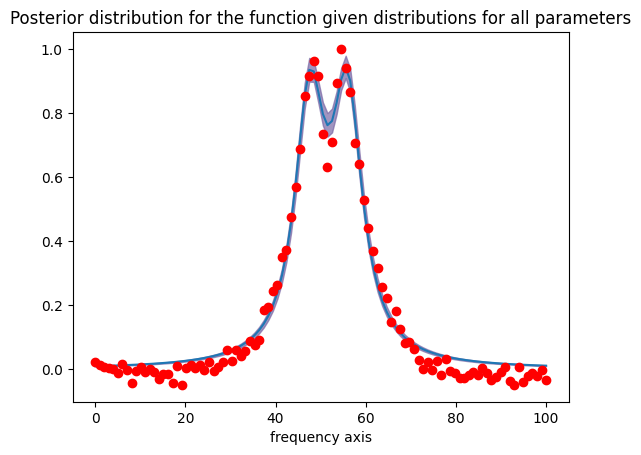

#################
4


Sample: 100%|██████████| 2200/2200 [00:59, 37.07it/s, step size=6.06e-01, acc. prob=0.904]

#################


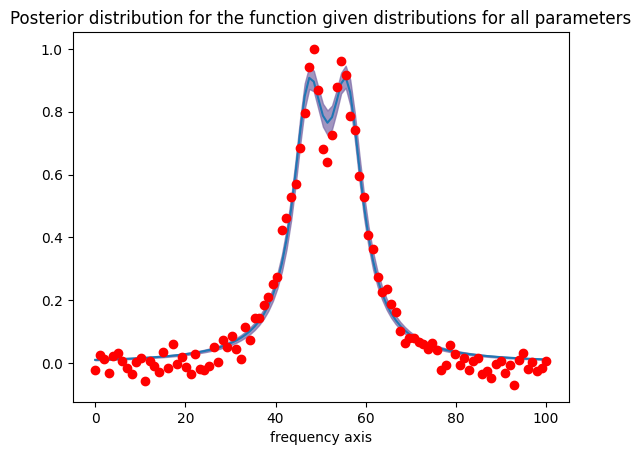

#################
5


Sample: 100%|██████████| 2200/2200 [01:07, 32.37it/s, step size=5.90e-01, acc. prob=0.912]


#################


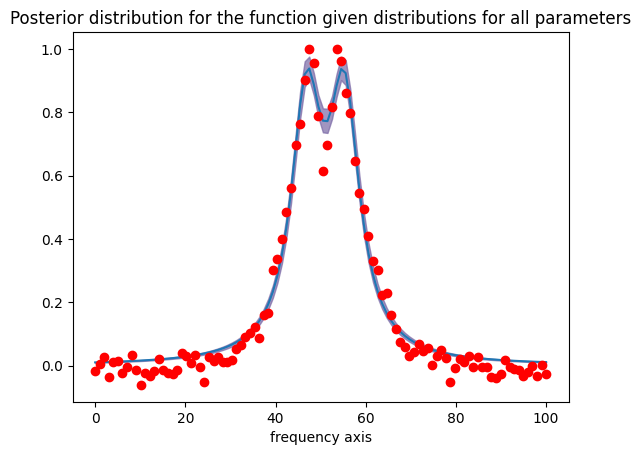

#################
6


Sample: 100%|██████████| 2200/2200 [01:05, 33.60it/s, step size=5.74e-01, acc. prob=0.921]


#################


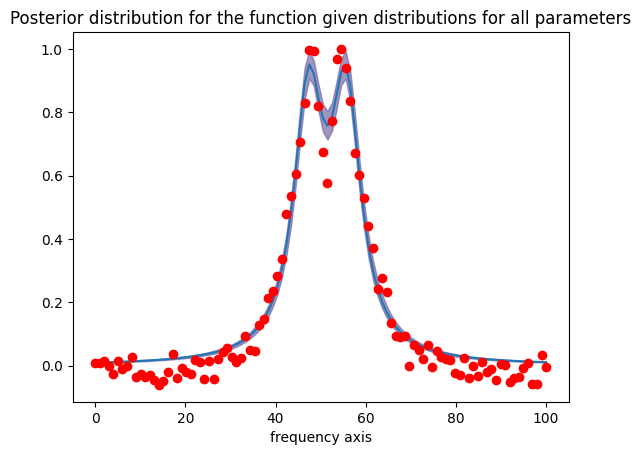

#################
7


Sample: 100%|██████████| 2200/2200 [00:57, 38.01it/s, step size=6.34e-01, acc. prob=0.905]


#################


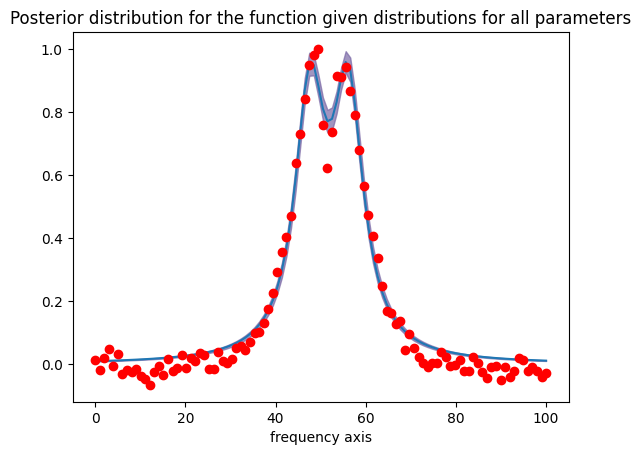

#################
8


Sample: 100%|██████████| 2200/2200 [01:07, 32.36it/s, step size=4.68e-01, acc. prob=0.939]


#################


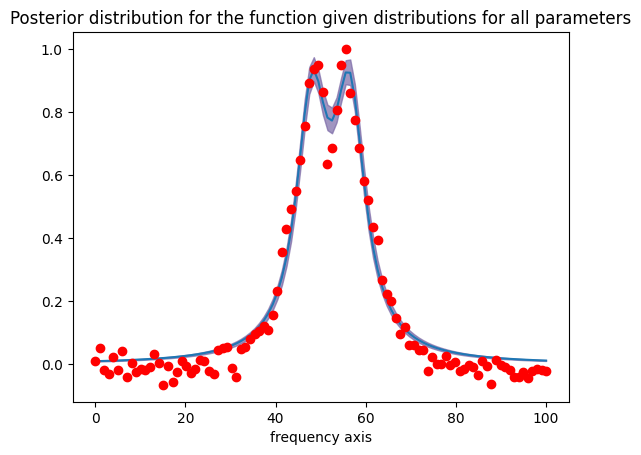

#################
9


Sample: 100%|██████████| 2200/2200 [01:07, 32.49it/s, step size=4.43e-01, acc. prob=0.934]


#################


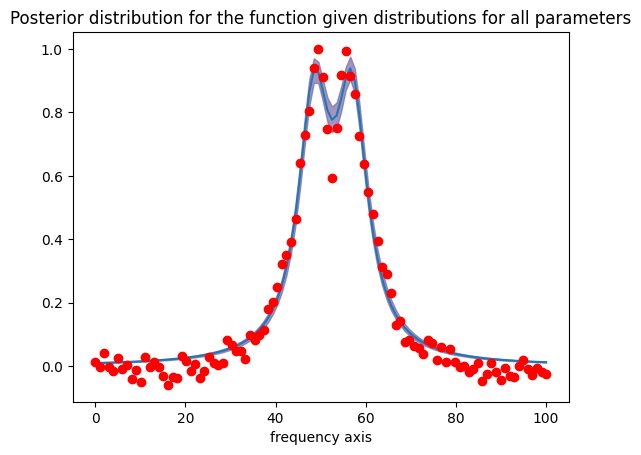

#################
10


Sample: 100%|██████████| 2200/2200 [01:04, 34.30it/s, step size=4.90e-01, acc. prob=0.914]


#################


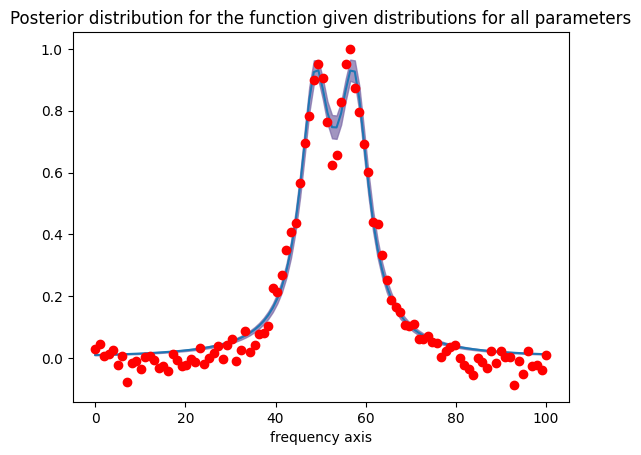

#################
11


Sample: 100%|██████████| 2200/2200 [00:55, 39.59it/s, step size=6.38e-01, acc. prob=0.890]


#################


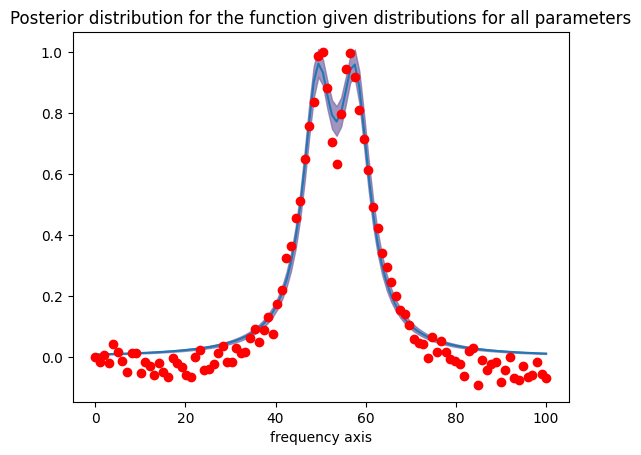

#################


In [14]:
idx = []
error_A = []
error_B = []
X_freq, A_freq, B_freq = [], [], []
gamma1_vals = []
X_var, A_var, gamma1_var, amp_var = [], [], [], []
for j in range(0, df.shape[1]-2):
  print(j)
  pyro.clear_param_store()
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr, col1=j, col2=j+1)
  data_j = (x_obs_j[20:].clone().detach().double(), y_obs_j[20:].clone().detach().double())
  # Use the model callable and pass data to MCMC.run
  init_vals = {
      "A": torch.tensor(50.0),
      "X": torch.tensor(8.0),
      "gamma1": torch.tensor(7.0),
      "amp": torch.tensor(1.0),
      "var": torch.tensor(0.05),}
  kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=6)
  posterior = MCMC(kernel, num_samples=2000, warmup_steps=200, num_chains=1)
  posterior.run(data_j)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  A_ = hmc_samples['A']
  X_ = hmc_samples['X']
  B_ = A_ + X_
  amp_ = hmc_samples['amp'] # Get posterior samples for amp
  gamma1_ = hmc_samples['gamma1'] # Get posterior samples for gamma1
  gamma2_ = hmc_samples['gamma1'] # Get posterior samples for gamma2 (since gamma2 = gamma1 in the model)
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np(x_scale, A_, X_, amp_, gamma1_, gamma2_)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  X_freq.append(X_.mean())
  A_freq.append(A_.mean())
  B_freq.append(B_.mean())
  gamma1_vals.append(gamma1_.mean())
  X_var.append(X_.var())
  A_var.append(A_.var())
  gamma1_var.append(gamma1_.var())
  amp_var.append(amp_.var())
  print('#################')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  pyro.clear_param_store()
  print('#################')

In [15]:
df_ = pd.DataFrame(zip(temps, A_freq, B_freq, X_freq), columns=['temp', 'a_freq', 'b_freq', 'x_freq'])
df_.head(2)

,temp,a_freq,b_freq,x_freq
0,25.0,48.842422,57.193847,8.351425
1,30.0,48.406711,56.822148,8.415437


In [ ]:
# drop obs 12-15 
# df_.drop(index= [12,13,14,15], inplace=True)

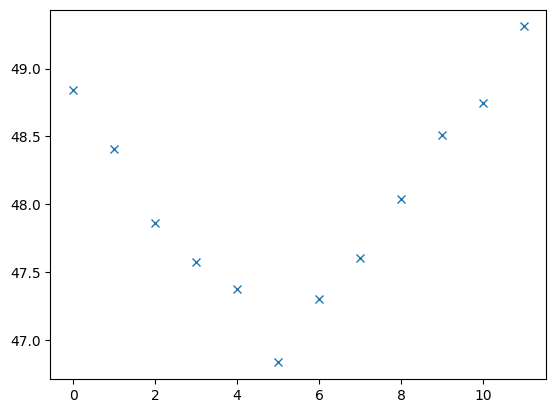

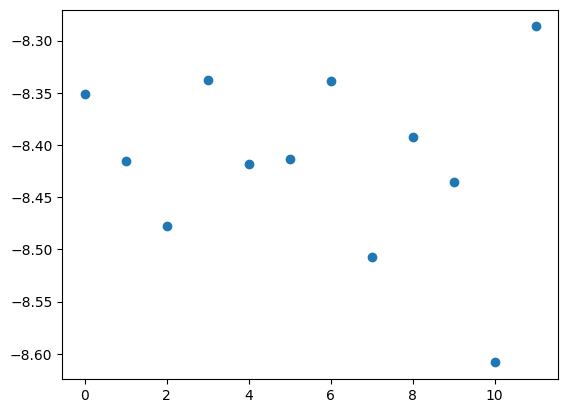

In [16]:
plt.plot(df_.a_freq, 'x'); 
#plt.plot(df_.b_freq, 'o')
plt.show()
plt.plot(df_.a_freq-df_.b_freq, 'o')

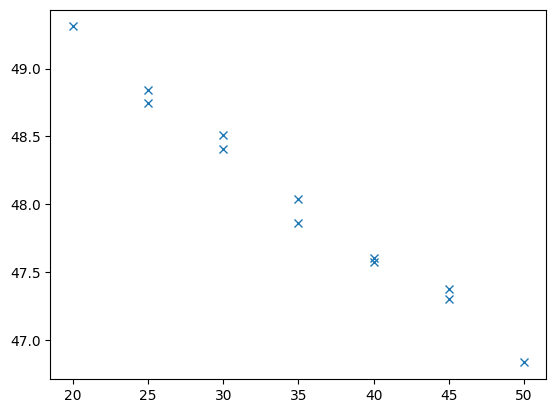

In [17]:
plt.plot(df_.temp, df_.a_freq, 'x')#; plt.plot(temps, np.array(B_freq)[:], 'ro')
plt.show()


## Let's build a linear regression model that maps centroid onto temperature



Testing RMSE:0.7376


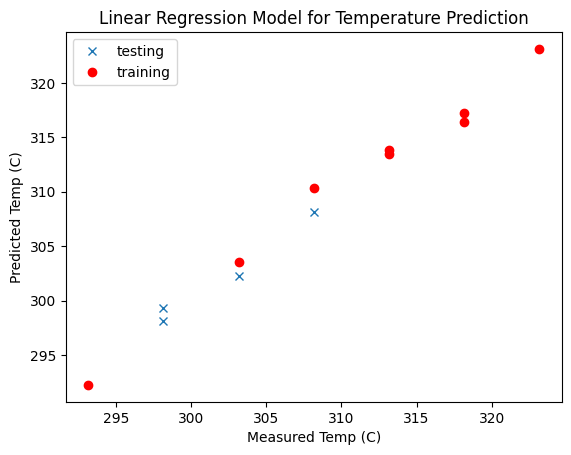

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

A_var = df_.a_freq.values.reshape(-1,1)
df_.temp = df_.temp +273.15
x_train, x_test, y_train, y_test = train_test_split(A_var, df_.temp, test_size=0.3, random_state=42)

ln = LinearRegression()

ln.fit(x_train, y_train)
temp_pred = ln.predict(x_test)

plt.plot(y_test, temp_pred, 'x'); plt.plot(y_train, ln.predict(x_train), 'ro')
plt.legend(['testing', 'training'])
mse = mean_squared_error(y_test, temp_pred)
print(f'Testing RMSE:{np.sqrt(mse):.4f}')
plt.xlabel('Measured Temp (C)'); plt.ylabel('Predicted Temp (C)'); plt.title('Linear Regression Model for Temperature Prediction');

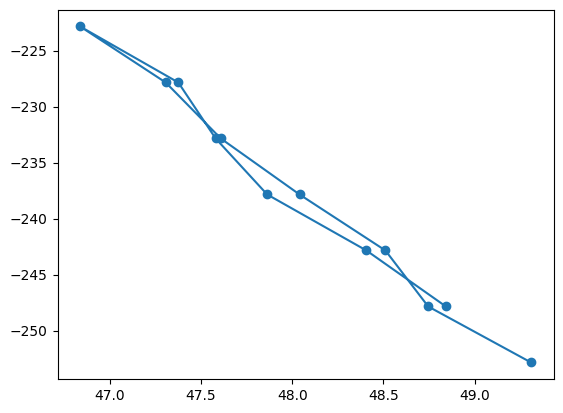

In [19]:
plt.plot(A_var, df_.temp-273*2, 'o-', label='peak A')

In [20]:
1/ln.coef_

array([-0.08007874])

In [22]:
1/ln.intercept_

np.float64(0.0011013077046751348)